In [2]:
!pip install wordcloud

In [3]:
import numpy as np
import pandas as pd
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import pymorphy2
from mawo_pymorphy3 import MorphAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SpatialDropout1D, Dropout
from tensorflow.keras.layers import GRU, Bidirectional, LSTM, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

In [4]:
morph = MorphAnalyzer()
df = pd.read_csv(
    "C:\\Users\\Камилла\\Desktop\\comments.txt",
    sep='\t',
    encoding='utf-8',
    quotechar='"',
    on_bad_lines='skip',
    converters={'comment': lambda x: x.strip().replace('\r\n', ' ').replace('\n', ' ')}
)

In [5]:
print(df.head())

                                             comment  toxic
0                 Верблюдов-то за что? Дебилы, бл...      1
1  Хохлы, это отдушина затюканого россиянина, мол...      1
2                            Собаке - собачья смерть      1
3  Страницу обнови, дебил. Это тоже не оскорблени...      1
4  тебя не убедил 6-страничный пдф в том, что Скр...      1


In [6]:
print(df['toxic'].value_counts())

toxic
0    9586
1    4826
Name: count, dtype: int64


### ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ

In [7]:
def basic_clean(text):
    text = text.replace("ё", "е").replace("Ё", "Е")
    text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))', 'URL', text)
    text = re.sub('[^a-zA-Zа-яА-Я\s]+', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.lower().strip()
    return text


In [8]:
def lemmatize_text(text):
    if morph is None:
        return text
    words = text.split()
    lemmas = []
    for word in words:
        try:
            parsed = morph.parse(word)[0]
            lemmas.append(parsed.normal_form)
        except:
            lemmas.append(word)
    return ' '.join(lemmas)


In [9]:
def tokenize_text(text):
    try:
        tokens = word_tokenize(text, language='russian')
    except:
        tokens = word_tokenize(text)
    return tokens

In [10]:
def remove_stopwords(tokens):
    russian_stopwords = set(stopwords.words('russian'))
    english_stopwords = set(stopwords.words('english'))
    custom_stopwords = {'это', 'что', 'как', 'так', 'вот', 'эти', 'которые', 
                        'весь', 'наш', 'ваш', 'мой', 'твой', 'свой', 'быть', 'очень'}
    all_stopwords = russian_stopwords.union(english_stopwords).union(custom_stopwords)
    return [token for token in tokens if token not in all_stopwords and len(token) > 1]


In [11]:
print("Выполняется предобработка текста...")
df['text_clean'] = df['comment'].apply(basic_clean)
df['text_lemmatized'] = df['text_clean'].apply(lemmatize_text)
df['tokens'] = df['text_lemmatized'].apply(tokenize_text)
df['tokens_filtered'] = df['tokens'].apply(remove_stopwords)
df['text_final'] = df['tokens_filtered'].apply(lambda x: ' '.join(x))

print("Предобработка завершена!")
print(f"Пример обработанного текста:\n{df['text_final'].iloc[0][:200]}...")


Выполняется предобработка текста...
Предобработка завершена!
Пример обработанного текста:
верблюдов дебил бл...


### ВИЗУАЛИЗАЦИЯ ДАННЫХ

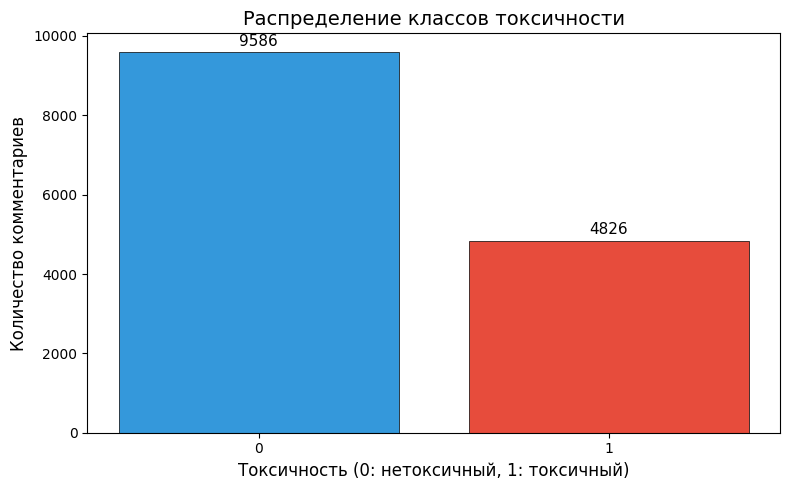

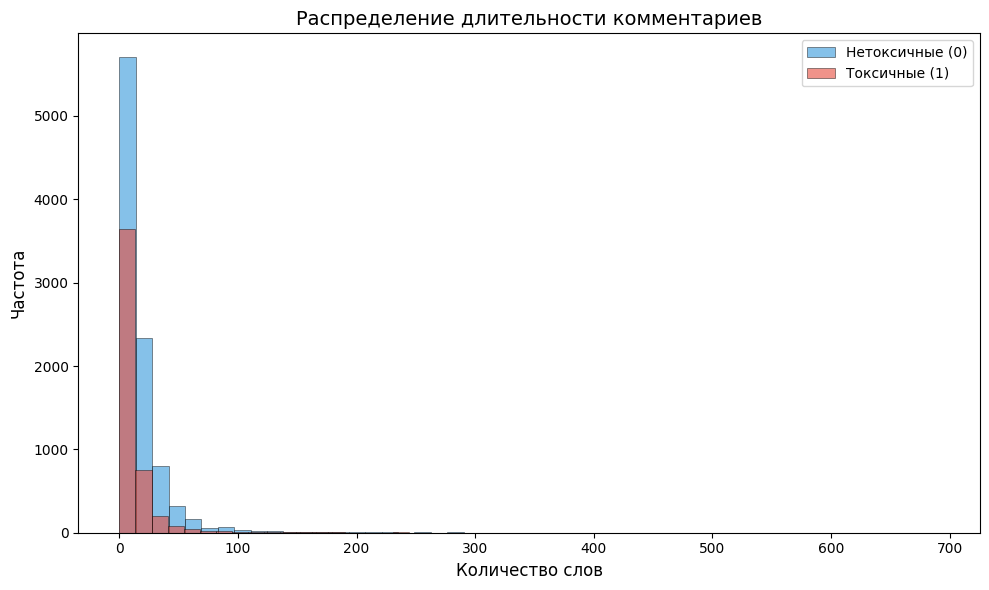

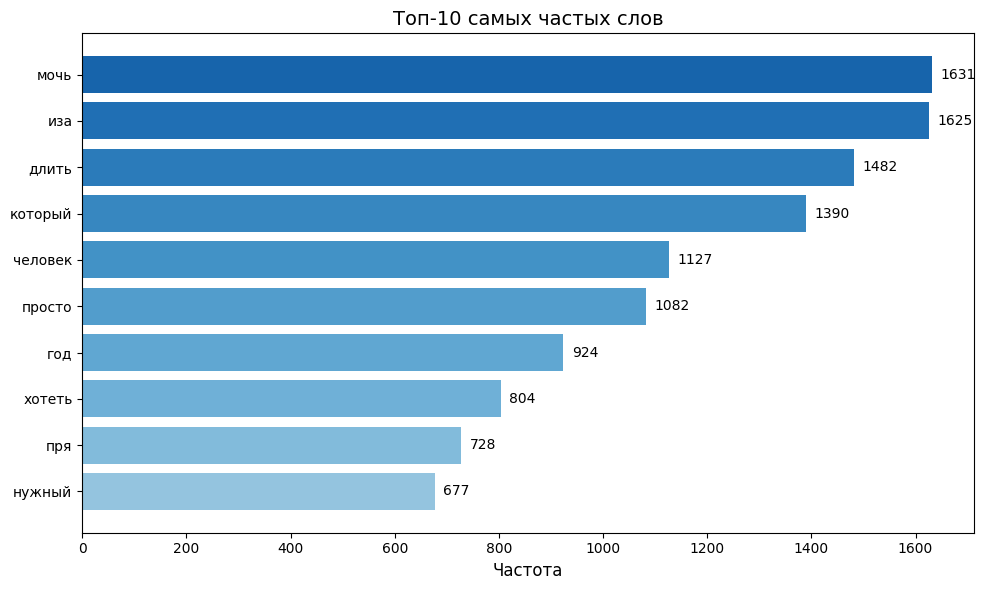

In [12]:
plt.figure(figsize=(8, 5))
class_counts = df['toxic'].value_counts().sort_index()
colors = ['#3498db', '#e74c3c']
bars = plt.bar(class_counts.index.astype(str), class_counts.values, color=colors, edgecolor='black', linewidth=0.5)
plt.title('Распределение классов токсичности', fontsize=14)
plt.xlabel('Токсичность (0: нетоксичный, 1: токсичный)', fontsize=12)
plt.ylabel('Количество комментариев', fontsize=12)
for bar, (index, value) in zip(bars, class_counts.items()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + max(class_counts.values)*0.01,
            f'{value}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


df['word_count'] = df['text_final'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 6))
plt.hist(df[df['toxic']==0]['word_count'], bins=50, alpha=0.6, label='Нетоксичные (0)', color='#3498db', edgecolor='black', linewidth=0.5)
plt.hist(df[df['toxic']==1]['word_count'], bins=50, alpha=0.6, label='Токсичные (1)', color='#e74c3c', edgecolor='black', linewidth=0.5)
plt.title('Распределение длительности комментариев', fontsize=14)
plt.xlabel('Количество слов', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


all_words = []
for text in df['text_final'].dropna():
    words = str(text).lower().split()
    all_words.extend([word for word in words if word.isalpha() and len(word) > 2])
top_words = Counter(all_words).most_common(10)

if top_words:
    words, counts = zip(*top_words)
    plt.figure(figsize=(10, 6))
    colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(words)))
    bars = plt.barh(range(len(words)), counts, color=colors[::-1])
    plt.yticks(range(len(words)), words)
    plt.xlabel('Частота', fontsize=12)
    plt.title('Топ-10 самых частых слов', fontsize=14)
    for i, (bar, count) in enumerate(zip(bars, counts)):
        plt.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2, 
                str(count), va='center', fontsize=10)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

### ОБЛАКО СЛОВ

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

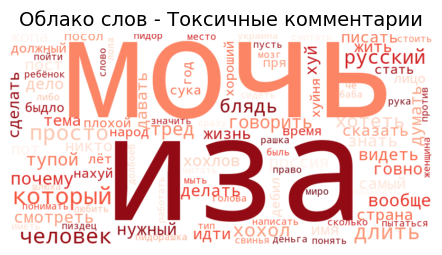

In [13]:
toxic_text = ' '.join(df[df['toxic']==1]['text_final'].dropna())
wordcloud_toxic = WordCloud(width=800, height=400, background_color='white', 
                           colormap='Reds', max_words=100).generate(toxic_text)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_toxic, interpolation='bilinear')
plt.title('Облако слов - Токсичные комментарии', fontsize=14)
plt.axis('off')

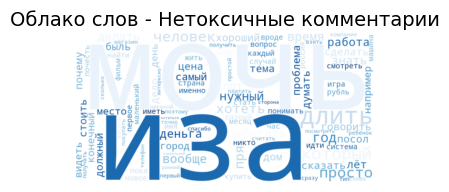

In [14]:
nontoxic_text = ' '.join(df[df['toxic']==0]['text_final'].dropna())
wordcloud_nontoxic = WordCloud(width=800, height=400, background_color='white', 
                              colormap='Blues', max_words=100).generate(nontoxic_text)
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_nontoxic, interpolation='bilinear')
plt.title('Облако слов - Нетоксичные комментарии', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

 ### РАЗДЕЛЕНИЕ НА ТРЕНИРОВОЧНУЮ И ТЕСТОВУЮ ВЫБОРКИ 

In [15]:
X = df['text_final'].values
y = df['toxic'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (11529,)
Testing data shape: (2883,)


### ВЕКТОРИЗАЦИЯ TF-IDF

In [16]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Размерность TF-IDF матрицы (train): {X_train_tfidf.shape}")
print(f"Размерность TF-IDF матрицы (test): {X_test_tfidf.shape}")

Размерность TF-IDF матрицы (train): (11529, 10000)
Размерность TF-IDF матрицы (test): (2883, 10000)


### ПОДГОТОВКА ДАННЫХ ДЛЯ РЕКУРРЕНТНЫХ МОДЕЛЕЙ (токенизация)

In [17]:
max_words = 10000
max_len = 128

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
    
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

print(f"Форма данных для рекуррентных моделей: {X_train_pad.shape}")
print(f"Размер словаря: {min(max_words, len(tokenizer.word_index))}")

Форма данных для рекуррентных моделей: (11529, 128)
Размер словаря: 10000


### Баланс классов (веса)

In [18]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"Веса классов: {class_weight_dict}")

Веса классов: {0: np.float64(0.7517605633802817), 1: np.float64(1.493006993006993)}


### ОБУЧЕНИЕ МОДЕЛЕЙ

In [19]:
results = {}

def evaluate_model(model, X_test, y_test, model_name, is_keras=False):
    if is_keras:
        y_pred_prob = model.predict(X_test).flatten()
        y_pred = (y_pred_prob > 0.5).astype(int)
    else:
        y_pred_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_pred_prob > 0.5).astype(int)
    
    accuracy = np.mean(y_pred == y_test)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    
    print(f"\n{model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['нетоксичные', 'токсичные']))
    
    return {'accuracy': accuracy, 'roc_auc': roc_auc, 'predictions': y_pred, 'probabilities': y_pred_prob}

### ПРОСТАЯ НЕЙРОСЕТЬ БЕЗ ИСПОЛЬЗОВАНИЯ Embedding

In [20]:
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_dense)
X_test_scaled = scaler.transform(X_test_dense)

simple_nn = tf.keras.Sequential([
    tf.keras.layers.Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

C:\anaconda\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
simple_nn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [22]:
print("\nАрхитектура простой нейросети без Embedding:")
simple_nn.summary()


Архитектура простой нейросети без Embedding:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │       1,280,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,291,009 (4.92 MB)

 Trainable params: 1,291,009 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
callbacks_list = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
]

In [24]:
history_simple_nn = simple_nn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1,
    class_weight=class_weight_dict
)


Epoch 1/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7457 - auc: 0.8128 - loss: 0.5372 - val_accuracy: 0.8239 - val_auc: 0.8947 - val_loss: 0.4362 - learning_rate: 0.0010
Epoch 2/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9256 - auc: 0.9765 - loss: 0.1979 - val_accuracy: 0.8352 - val_auc: 0.8929 - val_loss: 0.4733 - learning_rate: 0.0010
Epoch 3/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9763 - auc: 0.9965 - loss: 0.0674 - val_accuracy: 0.8330 - val_auc: 0.8763 - val_loss: 0.7434 - learning_rate: 0.0010
Epoch 4/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9889 - auc: 0.9992 - loss: 0.0328 - val_accuracy: 0.8322 - val_auc: 0.8581 - val_loss: 1.0589 - learning_rate: 0.0010
Epoch 5/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9927 - auc: 0.9993 - loss: 0.0212 - val_accuracy: 0.8309 - val_auc: 0.8613 - val_loss: 1.1621 - learning_rate: 0.0010
Epoch 6/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9930 - auc: 0.

In [25]:
results['Simple NN (без Embedding)'] = evaluate_model(simple_nn, X_test_scaled, y_test, 'Simple NN (без Embedding)', is_keras=True)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Simple NN (без Embedding):
Accuracy: 0.8158
ROC-AUC: 0.8767
              precision    recall  f1-score   support

 нетоксичные       0.89      0.83      0.86      1918
   токсичные       0.70      0.79      0.74       965

    accuracy                           0.82      2883
   macro avg       0.79      0.81      0.80      2883
weighted avg       0.82      0.82      0.82      2883



### МОДЕЛЬ LSTM с Embedding 

In [26]:
vocab_size = 10000 
embed_size = 128
max_len = 128

model_lstm = Sequential()
model_lstm.add(Embedding(vocab_size, embed_size, input_length=max_len))
model_lstm.add(LSTM(64, return_sequences=True))
model_lstm.add(LSTM(32))
model_lstm.add(Dense(1, activation='sigmoid'))


model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

dummy_input = np.zeros((1, max_len), dtype=np.int32)
_ = model_lstm(dummy_input)

C:\anaconda\envs\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
print("\nАрхитектура LSTM модели:")
model_lstm.summary() 


Архитектура LSTM модели:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (1, 128, 128)               │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (1, 128, 64)                │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (1, 32)                     │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (1, 1)                      │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,341,857 (5.12 MB)

 Trainable params: 1,341,857 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.7825 - loss: 0.4463 - val_accuracy: 0.8515 - val_loss: 0.3543
Epoch 2/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9218 - loss: 0.2016 - val_accuracy: 0.8630 - val_loss: 0.3410
Epoch 3/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9530 - loss: 0.1242 - val_accuracy: 0.8585 - val_loss: 0.3835
Epoch 4/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9709 - loss: 0.0830 - val_accuracy: 0.8578 - val_loss: 0.5006
Epoch 5/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9803 - loss: 0.0600 - val_accuracy: 0.8515 - val_loss: 0.5141


In [29]:
results['LSTM with Embedding'] = evaluate_model(model_lstm, X_test_pad, y_test, 'LSTM with Embedding', is_keras=True)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

LSTM with Embedding:
Accuracy: 0.8630
ROC-AUC: 0.9271
              precision    recall  f1-score   support

 нетоксичные       0.90      0.89      0.90      1918
   токсичные       0.79      0.81      0.80       965

    accuracy                           0.86      2883
   macro avg       0.84      0.85      0.85      2883
weighted avg       0.86      0.86      0.86      2883



### МОДЕЛЬ GRU с Embedding

In [30]:
vocab_size = 10000
embed_size = 128
max_len = 128

model_gru = Sequential()
model_gru.add(Embedding(vocab_size, embed_size, input_length=max_len))
model_gru.add(GRU(64, return_sequences=True))
model_gru.add(GRU(32))                          
model_gru.add(Dense(1, activation='sigmoid'))


C:\anaconda\envs\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

dummy_input = np.zeros((1, max_len), dtype=np.int32)
_ = model_gru(dummy_input)

In [32]:
print("\nАрхитектура GRU модели:")
model_gru.summary()


Архитектура GRU модели:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (1, 128, 128)               │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (1, 128, 64)                │          37,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (1, 32)                     │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (1, 1)                      │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,326,689 (5.06 MB)

 Trainable params: 1,326,689 (5.06 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_gru = model_gru.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.7848 - auc: 0.8779 - loss: 0.4373 - val_accuracy: 0.8678 - val_auc: 0.9263 - val_loss: 0.3304
Epoch 2/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.9244 - auc: 0.9765 - loss: 0.1941 - val_accuracy: 0.8626 - val_auc: 0.9223 - val_loss: 0.3422
Epoch 3/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9603 - auc: 0.9915 - loss: 0.1080 - val_accuracy: 0.8488 - val_auc: 0.9149 - val_loss: 0.4307
Epoch 4/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9739 - auc: 0.9958 - loss: 0.0711 - val_accuracy: 0.8512 - val_auc: 0.9066 - val_loss: 0.5303


In [34]:
results['GRU with Embedding'] = evaluate_model(model_gru, X_test_pad, y_test, 'GRU with Embedding', is_keras=True)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

GRU with Embedding:
Accuracy: 0.8678
ROC-AUC: 0.9264
              precision    recall  f1-score   support

 нетоксичные       0.91      0.89      0.90      1918
   токсичные       0.79      0.82      0.81       965

    accuracy                           0.87      2883
   macro avg       0.85      0.86      0.85      2883
weighted avg       0.87      0.87      0.87      2883



### СРАВНЕНИЕ МОДЕЛЕЙ

In [35]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()]
})


In [36]:
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("\nСравнение всех моделей:")
print(comparison_df.to_string(index=False))



Сравнение всех моделей:
                    Model  Accuracy  ROC-AUC
      LSTM with Embedding  0.862990 0.927057
       GRU with Embedding  0.867846 0.926414
Simple NN (без Embedding)  0.815817 0.876655


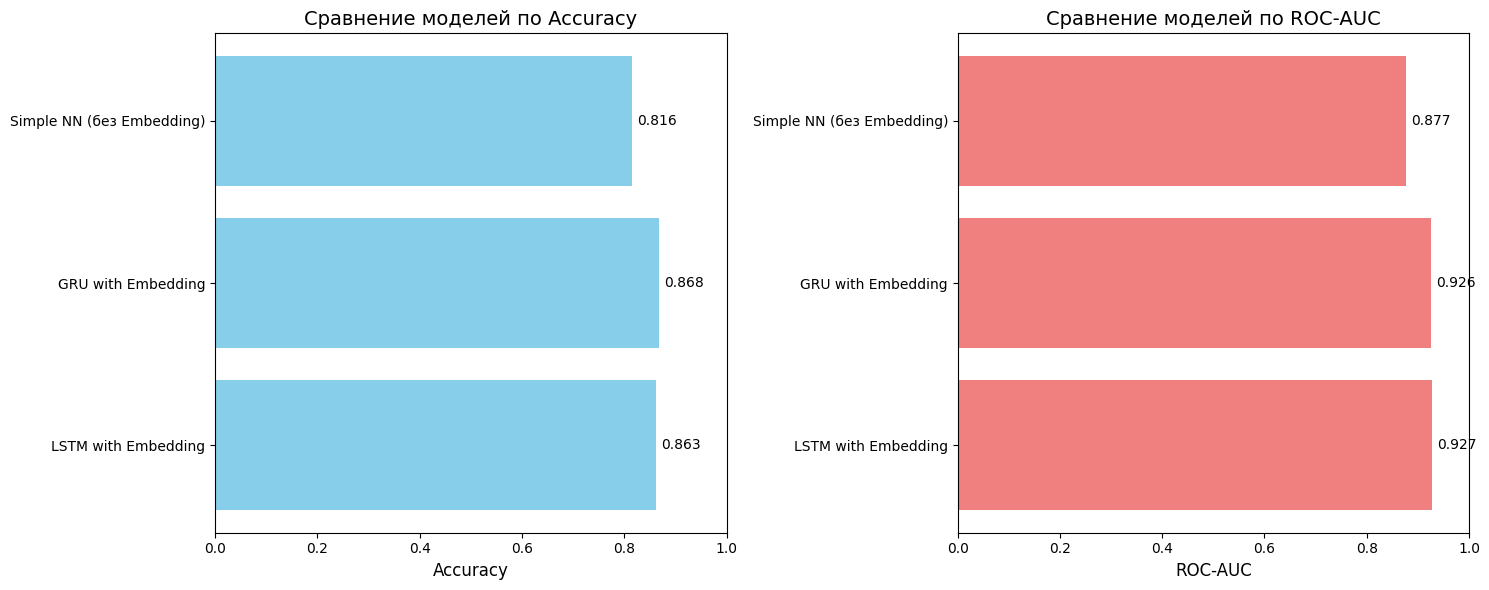

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars1 = axes[0].barh(comparison_df['Model'], comparison_df['Accuracy'], color='skyblue')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Сравнение моделей по Accuracy', fontsize=14)
axes[0].set_xlim(0, 1)
for i, (bar, val) in enumerate(zip(bars1, comparison_df['Accuracy'])):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

bars2 = axes[1].barh(comparison_df['Model'], comparison_df['ROC-AUC'], color='lightcoral')
axes[1].set_xlabel('ROC-AUC', fontsize=12)
axes[1].set_title('Сравнение моделей по ROC-AUC', fontsize=14)
axes[1].set_xlim(0, 1)
for i, (bar, val) in enumerate(zip(bars2, comparison_df['ROC-AUC'])):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

### Тестирование

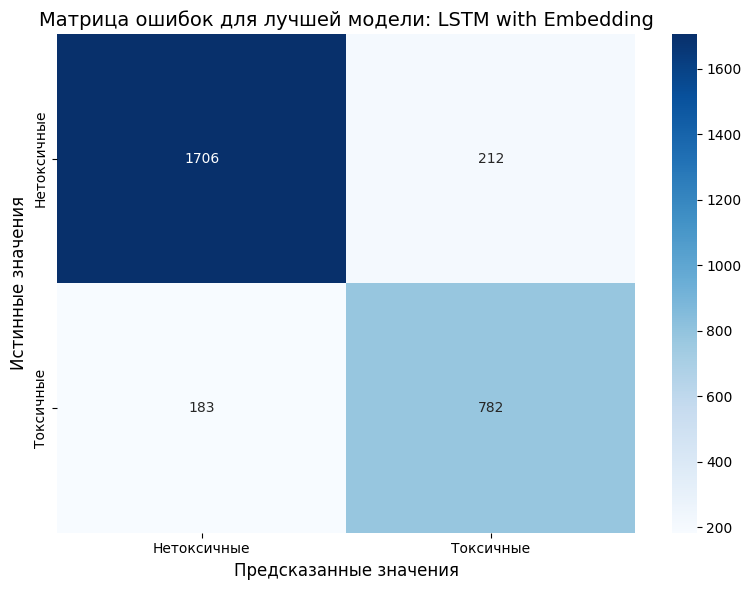

In [38]:
best_model_name = comparison_df.iloc[0]['Model']
y_pred_best = results[best_model_name]['predictions']

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Нетоксичные', 'Токсичные'],
            yticklabels=['Нетоксичные', 'Токсичные'])
plt.title(f'Матрица ошибок для лучшей модели: {best_model_name}', fontsize=14)
plt.ylabel('Истинные значения', fontsize=12)
plt.xlabel('Предсказанные значения', fontsize=12)
plt.tight_layout()
plt.show()

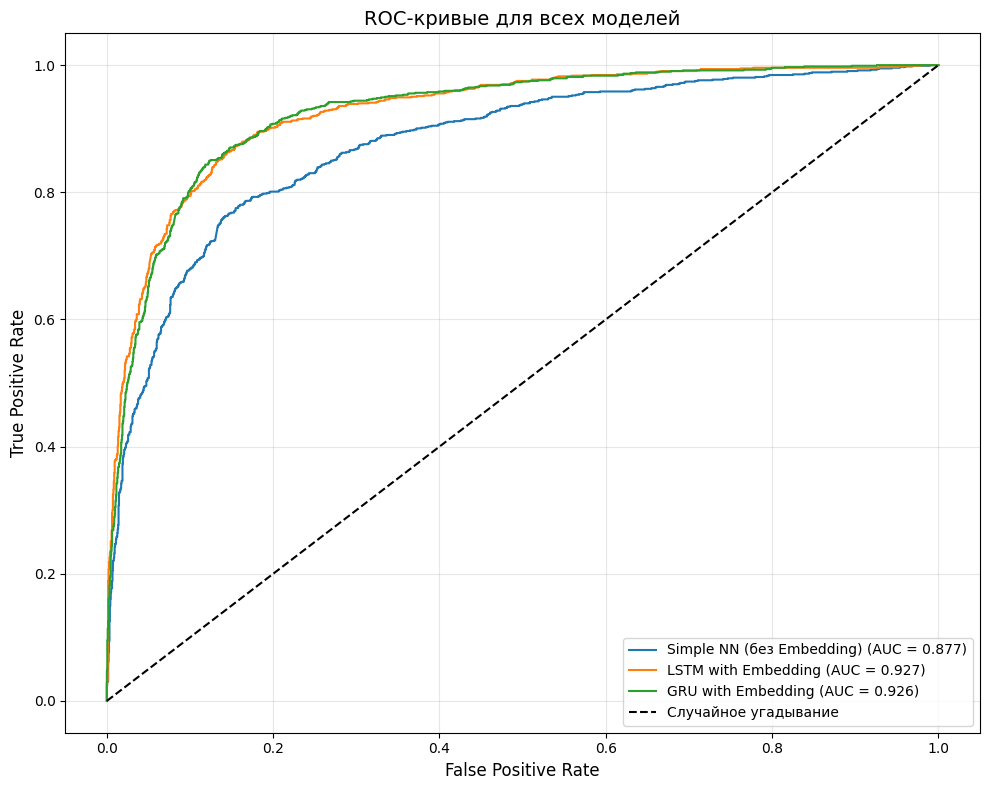


Лучшая модель: LSTM with Embedding
Accuracy: 0.8630
ROC-AUC: 0.9271


In [39]:
plt.figure(figsize=(10, 8))
from sklearn.metrics import roc_curve

for model_name in results.keys():
    y_score = results[model_name]['probabilities']
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {results[model_name]['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые для всех моделей', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nЛучшая модель: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

### ВЫВОД

GRU модель с Embedding показывает лучшие результаты. ROC-AUC 0.93 говорит об отличной способности модели различать классы.
- Все модели работают хорошо так как их Accuracy выше 81%
- ROC-AUC > 0.88 у всех моделей хорошее качество классификации.
- Однако рекуррентные модели значительно лучше простой неройсети accuracy на ~5%. ROC-AUC выше на ~4%.

In [41]:
model_gru.save('gru_toxic_model.keras')

print("Модель GRU успешно сохранена в формате .keras!")

Модель GRU успешно сохранена в формате .keras!
